In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Load data from sql loss_profit.db

In [73]:
# Load database .db from pipelines/data_engineer/database/loss_profit.db
from sqlalchemy import create_engine, text
from pathlib import Path

CURR_DIR = Path.cwd()
ROOT_DIR = CURR_DIR.parent.parent
DB_PATH = ROOT_DIR / 'data_engineer' / 'database' / 'loss_profit_renew.db'

# Load data base .db and check tables
engine = create_engine(f'sqlite:///{DB_PATH}')
with engine.connect() as connection:
    result = connection.execute(text("SELECT name FROM sqlite_master WHERE type='table';"))
    tables = result.fetchall()
    print("Tables in the database:")
    for table in tables:
        print(table[0])

if tables:
    for table_name in tables:
        with engine.connect() as connection:
            query = text(f"SELECT * FROM {table_name[0]}")
            df = pd.read_sql(query, connection)
            print(f"\nData from table '{table_name[0]}':")
            print(f"Database: {df.head()}")
else:
    print("No tables found in the database.")

Tables in the database:
loss_profit

Data from table 'loss_profit':
Database:        item_id  purchase_count  view_count   price  stocks     sales  \
0  item_000001              56          91  365256     119  20454336   
1  item_000002              83         212  249729     104  20727507   
2  item_000003             176         166  276724      97  48703424   
3  item_000004              63         132  314195     123  19794285   
4  item_000005               3         506  213034     162    639102   

   stock_value_retail profit_status  conversion_rate  
0            43465464        profit        61.538462  
1            25971816        profit        39.150943  
2            26842228        profit       106.024096  
3            38645985        profit        47.727273  
4            34511508        profit         0.592885  


## Database as df -> Transformed database by data_engineer dir

### - **Added new column on total_revenue, stock_value, profit_status**

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   item_id             300000 non-null  object 
 1   purchase_count      300000 non-null  int64  
 2   view_count          300000 non-null  int64  
 3   price               300000 non-null  int64  
 4   stocks              300000 non-null  int64  
 5   sales               300000 non-null  int64  
 6   stock_value_retail  300000 non-null  int64  
 7   profit_status       300000 non-null  object 
 8   conversion_rate     300000 non-null  float64
dtypes: float64(1), int64(6), object(2)
memory usage: 20.6+ MB


In [75]:
df.describe()

,purchase_count,view_count,price,stocks,sales,stock_value_retail,conversion_rate
count,300000.000000,300000.000000,300000.000000,300000.000000,3.000000e+05,3.000000e+05,300000.000000
mean,29.505340,798.099583,275214.493157,100.166573,8.118207e+06,2.756189e+07,25.166193
std,29.936504,799.071223,85160.601177,58.032946,8.973939e+06,1.877912e+07,197.720139
min,0.000000,0.000000,53402.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,8.000000,228.000000,224457.750000,50.000000,2.014958e+06,1.200870e+07,1.164725
50%,20.000000,552.000000,288549.000000,100.000000,5.194244e+06,2.433093e+07,3.631961
75%,41.000000,1107.000000,336060.750000,150.000000,1.104536e+07,4.128084e+07,11.067848
max,348.000000,10367.000000,572572.000000,200.000000,1.443639e+08,1.013616e+08,22200.000000


## Feature engineering

In [76]:
# Fix item_id at the source (run before everything)
NUM_ITEMS = 890
item_pool = [f"item_{str(i).zfill(6)}" for i in range(1, NUM_ITEMS + 1)]

np.random.seed(42)
df['item_id'] = np.random.choice(item_pool, size=len(df), replace=True)

print(f"Unique items: {df['item_id'].nunique()}")
print(f"Avg transactions per item: {len(df) / df['item_id'].nunique():.1f}")
print(item_pool[:5])

Unique items: 890
Avg transactions per item: 337.1
['item_000001', 'item_000002', 'item_000003', 'item_000004', 'item_000005']


In [77]:
# Verify strictly
assert df['item_id'].nunique() == NUM_ITEMS, f"Got {df['item_id'].nunique()} items, expected {NUM_ITEMS}"
print(f"Unique items: {df['item_id'].nunique()}")

Unique items: 890


In [78]:
TOTAL_ROWS = len(df)

# Add date features
daily_df_temp = pd.DataFrame({
    'date': pd.date_range('2025-01-01', '2025-12-31')
})
num_days = len(daily_df_temp)
base = TOTAL_ROWS // num_days
remainder = TOTAL_ROWS % num_days

# Distribute the remainder across the days
tpd = np.full(num_days, base)
tpd[:remainder] += 1
daily_df_temp['transactions_per_day'] = tpd

expanded_dates = np.repeat(daily_df_temp['date'].values, daily_df_temp['transactions_per_day'].values)
df['date'] = expanded_dates

print(df[['date']].dtypes)
print(f"Shape after adding date: {df.shape}")

date    datetime64[ns]
dtype: object
Shape after adding date: (300000, 10)


## Data encoding

In [79]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
encoder = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object' and col != 'item_id':
        df_encoded[col] = encoder.fit_transform(df_encoded[col])

# Encode item_id separately to ensure consistent mapping
df_encoded['item_id'] = encoder.fit_transform(df_encoded['item_id'])
df_encoded = df_encoded.sort_values(by=['item_id', 'date']).reset_index(drop=True)

print(f"Unique item_ids: {df_encoded['item_id'].nunique()}")  # must be 822
print(df_encoded.head())

Unique item_ids: 890
   item_id  purchase_count  view_count   price  stocks     sales  \
0        0               2         761  184789       5    369578   
1        0               9          17  331433     120   2982897   
2        0              43        1865  241802       4  10397486   
3        0              21          53  396988     168   8336748   
4        0              61        1082  253253      83  15448433   

   stock_value_retail  profit_status  conversion_rate       date  
0              923945              1         0.262812 2025-01-01  
1            39771960              1        52.941176 2025-01-02  
2              967208              1         2.305630 2025-01-02  
3            66693984              1        39.622642 2025-01-02  
4            21019999              1         5.637708 2025-01-03  


## Feature engineering for transaction per day (prevent data leakage)

In [80]:
# Aggregate transactions to item-day level
df_agg = df_encoded.groupby(['item_id', 'date']).agg(
    purchase_count     = ('item_id', 'count'),
    view_count         = ('view_count', 'sum'),
    price              = ('price', 'mean'),
    stocks             = ('stocks', 'last'),
    sales              = ('sales', 'sum'),
    stock_value_retail = ('stock_value_retail', 'last'),
    profit_status      = ('profit_status', 'mean'),
    conversion_rate    = ('conversion_rate', 'mean')
).reset_index()

print(f"Unique items after agg: {df_agg['item_id'].nunique()}")  # 822
print(f"df_agg shape: {df_agg.shape}") 

Unique items after agg: 890
df_agg shape: (195550, 10)


In [81]:

# Every item must have every date (fill missing days with 0 activity)
full_dates = pd.date_range(df_agg['date'].min(), df_agg['date'].max(), freq='D')
all_items = df_agg['item_id'].unique()

# Create a index of all item-date combinations
idx = pd.MultiIndex.from_product([all_items, full_dates], names=['item_id', 'date'])
df_daily = df_agg.set_index(['item_id', 'date']).reindex(idx).reset_index()

# ── Fill rules ─────────────────────────────────────────────────────────────
# Activity metrics: zero on days with no transactions (gap = no sales)
zero_fill    = [col for col in df_daily.columns
                if col not in ['item_id', 'date',
                               'stocks', 'stock_value_retail', 'price',
                               'profit_status']]

# Carry-forward fields: keep last known value across gap days.
# profit_status is CRITICAL here — zero-filling it turns every no-activity
# day into class-0 (loss), creating massive artificial class imbalance that
# causes the classifier to collapse to all-"loss" predictions.
forward_fill = ['price', 'stocks', 'stock_value_retail', 'profit_status']

df_daily[zero_fill]   = df_daily[zero_fill].fillna(0)
df_daily[forward_fill] = df_daily.groupby('item_id')[forward_fill].ffill().bfill()

# Add log-transformed sales as a LAGGED FEATURE so the LSTM can see past
# sales history inside the lookback window (not leakage: target is t+LOOKBACK).
df_daily['sales_log'] = np.log1p(df_daily['sales']).astype(np.float32)

print(f"df_daily shape: {df_daily.shape}")
print(f"df_daily columns: {df_daily.columns.tolist()}")

# Verify profit_status class balance BEFORE sampling
ps = df_daily['profit_status']
print(f"\nprofit_status distribution (full df_daily):")
print(f"  mean (0-1 raw): {ps.mean():.4f}")
print(f"  class 1 (≥0.5): {(ps>=0.5).mean()*100:.1f}%")
print(f"  class 0 (<0.5): {(ps<0.5).mean()*100:.1f}%")


df_daily shape: (324850, 11)
df_daily columns: ['item_id', 'date', 'purchase_count', 'view_count', 'price', 'stocks', 'sales', 'stock_value_retail', 'profit_status', 'conversion_rate', 'sales_log']

profit_status distribution (full df_daily):
  mean (0-1 raw): 0.9680
  class 1 (≥0.5): 98.0%
  class 0 (<0.5): 2.0%


In [82]:
import gc
import psutil

def check_memory():
    ram = psutil.virtual_memory()
    print(f"Available RAM: {ram.available / (1024 ** 3):.2f} GB")
    print(f"Used RAM: {ram.percent}%")

check_memory()

Available RAM: 3.27 GB
Used RAM: 79.5%


## Time-Based Split & Split into train sales and profit

In [83]:

# Use df_daily columns (aggregated) — ensures 'purchase_count' is included
# and avoids mismatches from transaction-level df_encoded columns
FEATURES = [col for col in df_daily.columns if col not in ['profit_status', 'item_id', 'date', 'sales']]
TARGET_SALES = "sales"
TARGET_PROFIT = "profit_status"
LOOKBACK = 30

# Split by date before scaling to prevent data leakage
df_daily = df_daily.sort_values(by=['date', 'item_id']).reset_index(drop=True)
unique_dates = df_daily['date'].unique()
split_date = unique_dates[int(0.82 * len(unique_dates))]

df_train_raw = df_daily[df_daily['date'] <= split_date].copy()
df_test_raw  = df_daily[df_daily['date'] >  split_date].copy()

print(f"FEATURES ({len(FEATURES)}): {FEATURES}")
print(f"Train: {df_train_raw['date'].min()} -> {df_train_raw['date'].max()}")
print(f"Test:  {df_test_raw['date'].min()}  -> {df_test_raw['date'].max()}")


FEATURES (7): ['purchase_count', 'view_count', 'price', 'stocks', 'stock_value_retail', 'conversion_rate', 'sales_log']
Train: 2025-01-01 00:00:00 -> 2025-10-27 00:00:00
Test:  2025-10-28 00:00:00  -> 2025-12-31 00:00:00


# Data scaling using minmaxscaler

df_train_raw  →  scale  →  df_train  →  sample  →  df_train_sampled  →  sequences
                              ↑ delete raw            ↑ delete full           ↑ delete sampled
                              here                    here                    here

In [84]:

import gc
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler_X     = MinMaxScaler()
scaler_sales = StandardScaler()   # StandardScaler on log1p(sales): unconstrained output → no clipping needed

# ================================================================
# IDEMPOTENCY FIX — Always rebuild df_train_raw / df_test_raw
# from the unscaled df_daily before fitting scalers.
# ================================================================
df_train_raw = df_daily[df_daily['date'] <= split_date].copy()
df_test_raw  = df_daily[df_daily['date'] >  split_date].copy()

# Step 1 — Downcast to float32 to halve memory
def downcast_df(df):
    df = df.copy()
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype(np.float32)
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = df[col].astype(np.int32)
    return df

df_train_raw = downcast_df(df_train_raw)
df_test_raw  = downcast_df(df_test_raw)

print(f"Memory after downcast:")
print(f"  train: {df_train_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  test:  {df_test_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Step 2 — Fit scalers on FULL training data BEFORE sampling
# StandardScaler on log1p(sales): mean≈0, std≈1 — model output is unconstrained
# so inverse_transform → expm1 gives correct original-scale values.
log_sales_train = np.log1p(df_train_raw[[TARGET_SALES]].values.astype(np.float64))
scaler_X.fit(df_train_raw[FEATURES])
scaler_sales.fit(log_sales_train)

# Verify scaler captured the true range (mean should be > 1 for million-scale sales)
log_max = scaler_sales.mean_[0] + 3 * np.sqrt(scaler_sales.var_[0])
print(f"\nScaler verification:")
print(f"  scaler_sales.mean_ (log space) = {scaler_sales.mean_[0]:.4f}")
print(f"  scaler_sales.scale_ (std)      = {scaler_sales.scale_[0]:.4f}")
print(f"  log1p(sales) mean              = {np.log1p(df_train_raw[TARGET_SALES]).mean():.4f}")
print(f"  original sales max in train    = {df_train_raw[TARGET_SALES].max():,.0f}")
assert scaler_sales.mean_[0] > 1.0, (
    f"SCALER ERROR: mean_ = {scaler_sales.mean_[0]:.4f} — "
    "sales mean in log space is too small; check if df_daily has real sales data."
)

# Step 3 — Random sample AFTER fitting scalers
MAX_ITEMS = 890  # 300 ~4GB RAM | 500 ~6GB | 700 ~8GB+

np.random.seed(42)
all_item_ids  = df_train_raw['item_id'].unique()
sampled_items = np.random.choice(all_item_ids, size=min(MAX_ITEMS, len(all_item_ids)), replace=False)

df_train_raw = df_train_raw[df_train_raw['item_id'].isin(sampled_items)].reset_index(drop=True)
df_test_raw  = df_test_raw[df_test_raw['item_id'].isin(sampled_items)].reset_index(drop=True)

print(f"\nSampled train shape: {df_train_raw.shape}")
print(f"Sampled test shape:  {df_test_raw.shape}")
print(f"Items used: {df_train_raw['item_id'].nunique()} / {MAX_ITEMS}")

# Step 4 — Transform only (DO NOT re-fit on sample)
# Sales: log1p → StandardScaler (model sees ~N(0,1) values; output is unbounded)
df_train_raw[FEATURES]      = scaler_X.transform(df_train_raw[FEATURES]).astype(np.float32)
df_train_raw[TARGET_SALES]  = scaler_sales.transform(
    np.log1p(df_train_raw[[TARGET_SALES]].values.astype(np.float64))
).astype(np.float32)
df_train_raw[TARGET_PROFIT] = (df_train_raw[TARGET_PROFIT] >= 0.5).astype(np.float32)

df_test_raw[FEATURES]       = scaler_X.transform(df_test_raw[FEATURES]).astype(np.float32)
df_test_raw[TARGET_SALES]   = scaler_sales.transform(
    np.log1p(df_test_raw[[TARGET_SALES]].values.astype(np.float64))
).astype(np.float32)
df_test_raw[TARGET_PROFIT]  = (df_test_raw[TARGET_PROFIT] >= 0.5).astype(np.float32)

# Step 5 — Diagnostics
print(f"\nSales target (train, StandardScaler space):")
print(f"  min={df_train_raw[TARGET_SALES].min():.4f}  mean={df_train_raw[TARGET_SALES].mean():.4f}  max={df_train_raw[TARGET_SALES].max():.4f}")
sample_decode = np.expm1(scaler_sales.inverse_transform([[df_train_raw[TARGET_SALES].max()]]))[0, 0]
print(f"  max decoded back to original: {sample_decode:,.0f}")

profit_counts = df_train_raw[TARGET_PROFIT].value_counts()
print(f"\nProfit class balance (train):")
print(f"  class 1 (profit): {profit_counts.get(1.0, 0):,} ({100*profit_counts.get(1.0,0)/len(df_train_raw):.1f}%)")
print(f"  class 0 (loss):   {profit_counts.get(0.0, 0):,} ({100*profit_counts.get(0.0,0)/len(df_train_raw):.1f}%)")

df_train = df_train_raw
df_test  = df_test_raw
gc.collect()

print(f"\nMemory after scaling:")
print(f"  train: {df_train.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  test:  {df_test.memory_usage(deep=True).sum() / 1e6:.1f} MB")


Memory after downcast:
  train: 15.0 MB
  test:  3.2 MB

Scaler verification:
  scaler_sales.mean_ (log space) = 9.3284
  scaler_sales.scale_ (std)      = 7.8253
  log1p(sales) mean              = 9.3284
  original sales max in train    = 170,742,416

Sampled train shape: (267000, 11)
Sampled test shape:  (57850, 11)
Items used: 890 / 890

Sales target (train, StandardScaler space):
  min=-1.1921  mean=0.0000  max=1.2303
  max decoded back to original: 170,742,472

Profit class balance (train):
  class 1 (profit): 261,648 (98.0%)
  class 0 (loss):   5,352 (2.0%)

Memory after scaling:
  train: 12.8 MB
  test:  2.8 MB


## LSTM Sequence Construction

*  #### Construction data into range by columns chosen
*  #### Prevent data leakage

In [85]:
def create_sequence(data, lookback=30):
    X, y_sales, y_profit = [], [], []
    for item_id, group in data.groupby('item_id'):
        group = group.sort_values('date').reset_index(drop=True)
        for i in range(len(group) - lookback):
            X.append(group[FEATURES].iloc[i:i+lookback].values)
            y_sales.append(group[TARGET_SALES].iloc[i+lookback])
            y_profit.append(group[TARGET_PROFIT].iloc[i+lookback])
    return (
        np.array(X,        dtype=np.float32),
        np.array(y_sales,  dtype=np.float32),
        np.array(y_profit, dtype=np.float32)
    )

X_train, y_sales_train, y_profit_train = create_sequence(df_train, lookback=LOOKBACK)
X_test,  y_sales_test,  y_profit_test  = create_sequence(df_test,  lookback=LOOKBACK)
gc.collect()

print(f"X_train shape:  {X_train.shape}")
print(f"X_test shape:   {X_test.shape}")
print(f"X_train memory: {X_train.nbytes / 1e6:.1f} MB")
print(f"X_test memory:  {X_test.nbytes / 1e6:.1f} MB")
print(f"y_sales_train shape:  {y_sales_train.shape}")
print(f"y_profit_train shape: {y_profit_train.shape}")
print(f"y_sales_test shape:   {y_sales_test.shape}")
print(f"y_profit_test shape:  {y_profit_test.shape}")

X_train shape:  (240300, 30, 7)
X_test shape:   (31150, 30, 7)
X_train memory: 201.9 MB
X_test memory:  26.2 MB
y_sales_train shape:  (240300,)
y_profit_train shape: (240300,)
y_sales_test shape:   (31150,)
y_profit_test shape:  (31150,)


## Build Multi-Output LSTM Model

### If no improvement in classification data with LSTM model
* ### Try to use Machine learning models
    * ### RandomForest Classifier
    * ### DecisionTree Classifier
    * ### Logistic Regression

In [86]:

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input, BatchNormalization,
    Bidirectional, Attention, Permute, Multiply, Lambda, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

timesteps  = X_train.shape[1]
n_features = X_train.shape[2]

inputs = Input(shape=(timesteps, n_features))

# ── Encoder: Bidirectional LSTM stack ────────────────────────────────────────
x = Bidirectional(LSTM(128, return_sequences=True,
                       kernel_regularizer=l2(1e-4),
                       recurrent_regularizer=l2(1e-4)))(inputs)
x = Dropout(0.3)(x)
x = Bidirectional(LSTM(64, return_sequences=True,
                       kernel_regularizer=l2(1e-4),
                       recurrent_regularizer=l2(1e-4)))(x)
x = Dropout(0.2)(x)

# ── Temporal self-attention ───────────────────────────────────────────────────
# Score each timestep so the model can focus on high-sales periods
attn_scores = Dense(1, activation='tanh')(x)                     # (batch, T, 1)
attn_weights = tf.nn.softmax(attn_scores, axis=1)                 # (batch, T, 1)
x_attended   = tf.reduce_sum(x * attn_weights, axis=1)            # (batch, 128)

# ── Shared dense head ────────────────────────────────────────────────────────
x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x_attended)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dense(32, activation='relu')(x)

# ── Outputs ──────────────────────────────────────────────────────────────────
# sales_output: linear (unconstrained — StandardScaler space)
# profit_output: sigmoid [0,1]
sales_output  = Dense(1, activation='linear', name='sales_output')(x)
profit_output = Dense(1, activation='sigmoid', name='profit_output')(x)

model = Model(inputs=inputs, outputs=[sales_output, profit_output])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={
        'sales_output':  tf.keras.losses.Huber(delta=1.0),  # robust to large sales spikes
        'profit_output': 'binary_crossentropy'
    },
    loss_weights={
        'sales_output':  1.5,   # boost sales gradient — model must learn the scale
        'profit_output': 1.0
    },
    metrics={
        'sales_output':  ['mae'],
        'profit_output': ['accuracy']
    }
)

model.summary()


Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 30, 7)]              0         []                            
                                                                                                  
 bidirectional_6 (Bidirecti  (None, 30, 256)              139264    ['input_4[0][0]']             
 onal)                                                                                            
                                                                                                  
 dropout_9 (Dropout)         (None, 30, 256)              0         ['bidirectional_6[0][0]']     
                                                                                                  
 bidirectional_7 (Bidirecti  (None, 30, 128)              164352    ['dropout_9[0][0]']     

## Model training

In [87]:

import gc
import tensorflow as tf

# ============================================================
# Ensure correct dtype + shape
# ============================================================
y_sales_train  = y_sales_train.astype(np.float32).reshape(-1, 1)
y_sales_test   = y_sales_test.astype(np.float32).reshape(-1, 1)
y_profit_train = y_profit_train.astype(np.float32).reshape(-1, 1)
y_profit_test  = y_profit_test.astype(np.float32).reshape(-1, 1)
X_train        = X_train.astype(np.float32)
X_test         = X_test.astype(np.float32)

print(f"X_train: {X_train.shape} | y_sales: {y_sales_train.shape} | y_profit: {y_profit_train.shape}")
# StandardScaler uses mean_ / scale_, not data_max_
print(f"Scaler mean_={scaler_sales.mean_[0]:.4f}  scale_={scaler_sales.scale_[0]:.4f}")
print(f"  → max decodeable (mean+5σ): {np.expm1(scaler_sales.mean_[0] + 5*scaler_sales.scale_[0]):,.0f}")

# ============================================================
# Class balance & adaptive threshold
# ============================================================
n_total  = len(y_profit_train)
n_pos    = int(y_profit_train.sum())
n_neg    = n_total - n_pos
pos_rate = n_pos / n_total

PROFIT_THRESHOLD = float(np.clip(pos_rate, 0.25, 0.75))

print(f"\nProfit class balance:")
print(f"  class 1: {n_pos:,} ({pos_rate*100:.1f}%)  class 0: {n_neg:,} ({(1-pos_rate)*100:.1f}%)")
print(f"  Adaptive threshold: {PROFIT_THRESHOLD:.4f}")

# ============================================================
# Class weights (baked into sample weights)
# ============================================================
w_pos = (n_total / (2.0 * n_pos)) if n_pos > 0 else 1.0
w_neg = (n_total / (2.0 * n_neg)) if n_neg > 0 else 1.0

sample_weight_train = np.where(
    y_profit_train.flatten() == 1, w_pos, w_neg
).astype(np.float32)

# ============================================================
# tf.data pipelines
# ============================================================
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices((
    X_train,
    {'sales_output': y_sales_train, 'profit_output': y_profit_train},
    sample_weight_train
)).shuffle(buffer_size=5000, seed=42) \
  .batch(BATCH_SIZE) \
  .prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((
    X_test,
    {'sales_output': y_sales_test, 'profit_output': y_profit_test}
)).batch(BATCH_SIZE) \
  .prefetch(tf.data.AUTOTUNE)

gc.collect()

# ============================================================
# Callbacks — staggered patience (LR drops at 4, stops at 10)
# ============================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    mode='min',
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    mode='min',
    verbose=1
)

# ============================================================
# Train — 50 epochs gives the model enough time to converge
# ============================================================
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


X_train: (240300, 30, 7) | y_sales: (240300, 1) | y_profit: (240300, 1)
Scaler mean_=9.3284  scale_=7.8253
  → max decodeable (mean+5σ): 1,105,763,854,213,276,368,896

Profit class balance:
  class 1: 235,503 (98.0%)  class 0: 4,797 (2.0%)
  Adaptive threshold: 0.7500
Epoch 1/50


2026-03-06 17:43:02.802484: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


939/939 [==============================] - 83s 85ms/step - loss: 1.4365 - sales_output_loss: 0.4249 - profit_output_loss: 0.7112 - sales_output_mae: 1.1096 - profit_output_accuracy: 0.5427 - val_loss: 3.7229 - val_sales_output_loss: 0.8690 - val_profit_output_loss: 2.3440 - val_sales_output_mae: 1.1802 - val_profit_output_accuracy: 0.0200 - lr: 0.0010
Epoch 2/50
939/939 [==============================] - 85s 91ms/step - loss: 1.3663 - sales_output_loss: 0.4030 - profit_output_loss: 0.6943 - sales_output_mae: 1.1109 - profit_output_accuracy: 0.5201 - val_loss: 1.7241 - val_sales_output_loss: 0.5830 - val_profit_output_loss: 0.7886 - val_sales_output_mae: 1.0644 - val_profit_output_accuracy: 0.1250 - lr: 0.0010
Epoch 3/50
939/939 [==============================] - 86s 92ms/step - loss: 1.3471 - sales_output_loss: 0.3989 - profit_output_loss: 0.6823 - sales_output_mae: 1.1071 - profit_output_accuracy: 0.5819 - val_loss: 0.9680 - val_sales_output_loss: 0.4999 - val_profit_output_loss: 0.14

## Prediction with model

In [88]:

# ============================================================
# CELL 1 — Evaluate on Test Set
# ============================================================
def decode_sales_std(scaled_preds, scaler):
    """
    Undo StandardScaler → undo log1p → original sales units.
    No clipping needed: StandardScaler is unconstrained (unlike MinMax).
    """
    arr = np.array(scaled_preds).reshape(-1, 1).astype(np.float64)
    log_space = scaler.inverse_transform(arr)          # undo StandardScaler
    original  = np.expm1(log_space).flatten()          # undo log1p
    return np.maximum(original, 0.0)                   # sales can't be negative

sales_pred_raw, profit_pred = model.predict(test_dataset, verbose=1)

sales_pred_inv  = decode_sales_std(sales_pred_raw, scaler_sales)
profit_pred_inv = (profit_pred > PROFIT_THRESHOLD).astype(int)

# Decode true test sales for comparison
y_true_inv = decode_sales_std(y_sales_test.flatten(), scaler_sales)

from sklearn.metrics import mean_absolute_error, r2_score
mae_orig = mean_absolute_error(y_true_inv, sales_pred_inv)
r2_orig  = r2_score(y_true_inv, sales_pred_inv)

# Diagnostic
print(f"\nScaler: mean_={scaler_sales.mean_[0]:.4f}  scale_={scaler_sales.scale_[0]:.4f}")
print(f"  → max decodeable (mean+5σ): {np.expm1(scaler_sales.mean_[0] + 5*scaler_sales.scale_[0]):,.0f}")
print(f"\nActual sales describe:")
print(pd.Series(y_true_inv).describe())
print(f"\nPredicted sales describe (original scale):")
print(pd.Series(sales_pred_inv).describe())
print(f"\nMAE  (original scale): {mae_orig:,.2f}")
print(f"R²   (original scale): {r2_orig:.4f}")

print(f"\nRaw sigmoid describe (profit):")
print(pd.Series(profit_pred.flatten()).describe())
print(f"  % predicted profit (threshold={PROFIT_THRESHOLD:.3f}): "
      f"{profit_pred_inv.mean()*100:.1f}%")

df_results = pd.DataFrame({
    'predicted_sales':  np.round(sales_pred_inv, 2),
    'predicted_profit': pd.Series(profit_pred_inv.flatten()).map({0: 'loss', 1: 'profit'})
})
print(f"\nProfit distribution:\n{df_results['predicted_profit'].value_counts()}")
df_results.head(10)


122/122 [==============================] - 4s 27ms/step

Scaler: mean_=9.3284  scale_=7.8253
  → max decodeable (mean+5σ): 1,105,763,854,213,276,368,896

Actual sales describe:
count    3.115000e+04
mean     7.525099e+06
std      1.171637e+07
min      4.583139e-07
25%      4.583139e-07
50%      2.063475e+06
75%      1.086945e+07
max      1.311476e+08
dtype: float64

Predicted sales describe (original scale):
count    3.115000e+04
mean     1.238223e+05
std      1.779983e+05
min      3.827993e+00
25%      1.940774e+04
50%      5.337293e+04
75%      1.497497e+05
max      2.178186e+06
dtype: float64

MAE  (original scale): 7,505,883.11
R²   (original scale): -0.3995

Raw sigmoid describe (profit):
count    31150.000000
mean         0.904604
std          0.069249
min          0.125438
25%          0.872643
50%          0.923367
75%          0.955425
max          0.989941
dtype: float64
  % predicted profit (threshold=0.750): 96.8%

Profit distribution:
profit    30156
loss        994
Name: 

,predicted_sales,predicted_profit
0,3994.65,loss
1,43863.27,profit
2,111915.42,profit
3,125205.27,profit
4,472974.99,profit
5,63024.34,profit
6,15212.30,profit
7,103955.79,profit
8,34187.97,profit
9,150607.09,profit


In [89]:

def decode_sales_std(scaled_preds, scaler):
    """Undo StandardScaler → undo log1p → original sales units."""
    arr = np.array(scaled_preds).reshape(-1, 1).astype(np.float64)
    log_space = scaler.inverse_transform(arr)
    return np.maximum(np.expm1(log_space).flatten(), 0.0)

# ============================================================
# Rebuild ground-truth aligned with sequence targets
# ============================================================
y_true_aligned = []
for _item_id, group in df_test.groupby('item_id'):
    group = group.sort_values('date').reset_index(drop=True)
    if len(group) <= LOOKBACK:
        continue
    y_true_aligned.extend(group[TARGET_SALES].iloc[LOOKBACK:].values)

y_true_aligned = np.array(y_true_aligned, dtype=np.float32)

# ============================================================
# Predict on raw X_test array
# model returns [sales_array, profit_array] for multi-output models
# ============================================================
pred_outputs   = model.predict(X_test, verbose=1)
sales_pred_arr = pred_outputs[0] if isinstance(pred_outputs, (list, tuple)) else pred_outputs

real_sales_pred = decode_sales_std(sales_pred_arr, scaler_sales)
real_sales_true = decode_sales_std(y_true_aligned,  scaler_sales)

assert real_sales_pred.shape == real_sales_true.shape, (
    f"Shape mismatch: pred={real_sales_pred.shape}, true={real_sales_true.shape}"
)

from sklearn.metrics import mean_absolute_error, r2_score
mae_currency = mean_absolute_error(real_sales_true, real_sales_pred)
r2_currency  = r2_score(real_sales_true, real_sales_pred)

print(f"Scaler: mean_={scaler_sales.mean_[0]:.4f}  scale_={scaler_sales.scale_[0]:.4f}")
print(f"\nActual sales describe:    {pd.Series(real_sales_true).describe().to_dict()}")
print(f"Predicted sales describe: {pd.Series(real_sales_pred).describe().to_dict()}")
print(f"\nMAE (original scale): {mae_currency:,.2f}")
print(f"R²  (original scale): {r2_currency:.4f}")
print(f"Sample: predicted={real_sales_pred[0]:,.2f}  actual={real_sales_true[0]:,.2f}")


974/974 [==============================] - 13s 12ms/step
Scaler: mean_=9.3284  scale_=7.8253

Actual sales describe:    {'count': 31150.0, 'mean': 7525098.557528652, 'std': 11716371.470990472, 'min': 4.583138653022639e-07, '25%': 4.583138653022639e-07, '50%': 2063475.1439630613, '75%': 10869454.755325679, 'max': 131147575.2101133}
Predicted sales describe: {'count': 31150.0, 'mean': 123822.27134019, 'std': 177998.32525693145, 'min': 3.8279934313316057, '25%': 19407.73721213247, '50%': 53372.92568180048, '75%': 149749.71339629992, 'max': 2178186.472467736}

MAE (original scale): 7,505,883.11
R²  (original scale): -0.3995
Sample: predicted=3,994.65  actual=3,906,495.71


## Model prediction testing

In [90]:

# ============================================================
# CELL 2 — Predict All Sampled Items (full year)
# ============================================================
def decode_sales_std(scaled_preds, scaler):
    """Undo StandardScaler → undo log1p → original sales units."""
    arr = np.array(scaled_preds).reshape(-1, 1).astype(np.float64)
    log_space = scaler.inverse_transform(arr)
    return np.maximum(np.expm1(log_space).flatten(), 0.0)

df_pred = df_daily[df_daily['item_id'].isin(sampled_items)].copy()
df_pred = df_pred.sort_values(['item_id', 'date']).reset_index(drop=True)

# Scale features using the scaler fit on full training data
df_pred[FEATURES] = scaler_X.transform(df_pred[FEATURES]).astype(np.float32)

# Build sequences + track metadata
X_all, item_ids_all, dates_all = [], [], []

for item_id, group in df_pred.groupby('item_id'):
    group = group.sort_values('date').reset_index(drop=True)
    if len(group) <= LOOKBACK:
        continue
    for i in range(len(group) - LOOKBACK):
        X_all.append(group[FEATURES].iloc[i:i+LOOKBACK].values)
        item_ids_all.append(item_id)
        dates_all.append(group['date'].iloc[i + LOOKBACK])

X_all = np.array(X_all, dtype=np.float32)
print(f"X_all shape: {X_all.shape}")

# Predict
pred_outputs    = model.predict(X_all, batch_size=512, verbose=1)
sales_pred_all  = pred_outputs[0] if isinstance(pred_outputs, (list, tuple)) else pred_outputs
profit_pred_all = pred_outputs[1] if isinstance(pred_outputs, (list, tuple)) else None

# Decode: undo StandardScaler → undo log1p → original sales units
sales_inv    = decode_sales_std(sales_pred_all, scaler_sales)
profit_class = (profit_pred_all > PROFIT_THRESHOLD).astype(int).flatten()

df_result = pd.DataFrame({
    'item_id'          : item_ids_all,
    'date'             : dates_all,
    'predicted_sales'  : np.round(sales_inv, 2),
    'predicted_profit' : pd.Series(profit_class).map({0: 'loss', 1: 'profit'})
})

gc.collect()

# Diagnostics
print(f"\nScaler: mean_={scaler_sales.mean_[0]:.4f}  scale_={scaler_sales.scale_[0]:.4f}")
print(f"\nPredicted sales describe (original scale):")
print(pd.Series(sales_inv).describe())
print(f"\nProfit distribution:\n{df_result['predicted_profit'].value_counts()}")
df_result.sort_values(['date', 'item_id']).reset_index(drop=True).head()


X_all shape: (298150, 30, 7)
583/583 [==============================] - 20s 34ms/step

Scaler: mean_=9.3284  scale_=7.8253

Predicted sales describe (original scale):
count    2.981500e+05
mean     1.253917e+05
std      1.799318e+05
min      3.537578e+00
25%      1.967172e+04
50%      5.431824e+04
75%      1.533449e+05
max      2.800949e+06
dtype: float64

Profit distribution:
profit    288669
loss        9481
Name: predicted_profit, dtype: int64


,item_id,date,predicted_sales,predicted_profit
0,0,2025-01-31,127866.25,profit
1,1,2025-01-31,46023.56,profit
2,2,2025-01-31,103140.53,profit
3,3,2025-01-31,59138.22,profit
4,4,2025-01-31,74198.89,profit


In [91]:

# -------------------------------------------------------
# Build CORRECT mapping: encoded int → original string
# encoder.classes_[i] is exactly the string that LabelEncoder
# assigned integer i — no zip/alignment issues.
# -------------------------------------------------------
item_id_mapping = {i: cls for i, cls in enumerate(encoder.classes_)}

df_result_new = df_result.copy()
df_result_new = df_result_new.sort_values(by='date', ascending=True).reset_index(drop=True)

print("Updated item_ids sample (encoded ints, decoded in Cell 3):")
print(df_result_new['item_id'].head())
df_result_new


Updated item_ids sample (encoded ints, decoded in Cell 3):
0      0
1    124
2    656
3    472
4    657
Name: item_id, dtype: int64


,item_id,date,predicted_sales,predicted_profit
0,0,2025-01-31,127866.25,profit
1,124,2025-01-31,80900.01,profit
2,656,2025-01-31,193195.19,profit
3,472,2025-01-31,112575.50,profit
4,657,2025-01-31,103757.38,profit
...,...,...,...,...
298145,586,2025-12-31,10614.66,profit
298146,585,2025-12-31,10690.59,profit
298147,584,2025-12-31,7785.46,profit
298148,595,2025-12-31,34548.59,profit


## Decode item_id back to original string labels

In [92]:

# ============================================================
# CELL 3 — Decode item_id back to original string labels
# ============================================================
# encoder.classes_[i] is the original string for encoded integer i.
# This is correct regardless of the sort order of df_encoded.
item_id_mapping = {i: cls for i, cls in enumerate(encoder.classes_)}

df_result['item_id'] = df_result['item_id'].map(item_id_mapping)

# Verify mapping worked
null_ids = df_result['item_id'].isna().sum()
print(f"Unmapped item_ids: {null_ids}")  # should be 0
print(f"Sample item_ids: {df_result['item_id'].unique()[:5]}")

df_result = df_result.sort_values('date').reset_index(drop=True)
print(f"df_result shape: {df_result.shape}")
df_result.head()


Unmapped item_ids: 0
Sample item_ids: ['item_000001' 'item_000002' 'item_000003' 'item_000004' 'item_000005']
df_result shape: (298150, 4)


,item_id,date,predicted_sales,predicted_profit
0,item_000001,2025-01-31,127866.25,profit
1,item_000125,2025-01-31,80900.01,profit
2,item_000657,2025-01-31,193195.19,profit
3,item_000473,2025-01-31,112575.50,profit
4,item_000658,2025-01-31,103757.38,profit


## Merge df_result wuth df_daily

* ### Recheck data first (especially in **Data scaling**) before ensure for data result reporting

In [93]:

# ============================================================
# CELL 4 — Merge Predictions with df_daily
# ============================================================
# item_id_mapping already built in Cell 3 via encoder.classes_
# Decode: df_daily uses encoded int item_ids, map to original strings
df_daily_decoded = df_daily[df_daily['item_id'].isin(sampled_items)].copy()
df_daily_decoded['item_id'] = df_daily_decoded['item_id'].map(item_id_mapping)

# The 'sales' column in df_daily_decoded is the raw aggregated sales (original scale).
# df_result['predicted_sales'] is inverse-transformed via expm1(scaler.inverse_transform(...)).
# Both are in the original sales units — the comparison is valid.
df_merged = df_daily_decoded.merge(
    df_result[['item_id', 'date', 'predicted_sales', 'predicted_profit']],
    on=['item_id', 'date'],
    how='left'
)
df_merged = df_merged.sort_values(['item_id', 'date']).reset_index(drop=True)

# First LOOKBACK days per item won't have predictions — expected
null_count = df_merged['predicted_sales'].isna().sum()
print(f"Null predictions: {null_count} rows (expected ~{len(sampled_items) * LOOKBACK})")

df_merged = df_merged.dropna(subset=['predicted_sales', 'predicted_profit']).reset_index(drop=True)
print(f"Shape after dropping nulls: {df_merged.shape}")

# Sanity-check: compare actual vs predicted sales distribution
print(f"\nActual vs predicted sales (original scale):")
print(df_merged[['sales', 'predicted_sales']].describe())

df_merged['predicted_sales']  = df_merged['predicted_sales'].astype(np.float32).round(2)
df_merged


Null predictions: 26700 rows (expected ~26700)
Shape after dropping nulls: (298150, 13)

Actual vs predicted sales (original scale):
              sales  predicted_sales
count  2.981500e+05     2.981500e+05
mean   7.493600e+06     1.253917e+05
std    1.164368e+07     1.799318e+05
min    0.000000e+00     3.540000e+00
25%    0.000000e+00     1.967172e+04
50%    2.111415e+06     5.431824e+04
75%    1.078300e+07     1.533449e+05
max    1.545250e+08     2.800949e+06


,item_id,date,purchase_count,view_count,price,stocks,sales,stock_value_retail,profit_status,conversion_rate,sales_log,predicted_sales,predicted_profit
0,item_000001,2025-01-31,3.0,3736.0,346555.0,172.0,30383339.0,49100152.0,1.00,60.195342,17.229404,127866.250000,profit
1,item_000001,2025-02-01,3.0,356.0,216545.0,96.0,24742335.0,25600992.0,1.00,70.376131,17.024027,56849.851562,profit
2,item_000001,2025-02-02,0.0,0.0,216545.0,96.0,0.0,25600992.0,1.00,0.000000,0.000000,104502.617188,profit
3,item_000001,2025-02-03,2.0,1044.0,284314.0,49.0,17303367.0,14108619.0,1.00,6.638782,16.666412,32212.800781,profit
4,item_000001,2025-02-04,2.0,1104.0,285865.0,148.0,18683496.0,41282232.0,1.00,6.484313,16.743151,75313.539062,profit
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298145,item_000890,2025-12-27,0.0,0.0,305113.5,183.0,0.0,61526064.0,0.75,0.000000,0.000000,13406.049805,profit
298146,item_000890,2025-12-28,1.0,361.0,347344.0,58.0,6252192.0,20145952.0,1.00,4.986150,15.648443,10358.120117,profit
298147,item_000890,2025-12-29,2.0,1571.0,204049.5,68.0,11992583.0,17865164.0,1.00,7.670717,16.299799,96990.546875,profit
298148,item_000890,2025-12-30,0.0,0.0,204049.5,68.0,0.0,17865164.0,1.00,0.000000,0.000000,165973.046875,profit


In [ ]:
df_merged.to_parquet("../../../MLOps/database/data/rawmatched_fashion_balance_rows_prediction.parquet")

,item_id,date,purchase_count,view_count,price,stocks,sales,stock_value_retail,profit_status,conversion_rate,sales_log,predicted_sales,predicted_profit
0,item_000001,2025-01-31,3.0,3736.0,346555.0,172.0,30383339.0,49100152.0,1.00,60.195342,17.229404,127866.250000,profit
1,item_000001,2025-02-01,3.0,356.0,216545.0,96.0,24742335.0,25600992.0,1.00,70.376131,17.024027,56849.851562,profit
2,item_000001,2025-02-02,0.0,0.0,216545.0,96.0,0.0,25600992.0,1.00,0.000000,0.000000,104502.617188,profit
3,item_000001,2025-02-03,2.0,1044.0,284314.0,49.0,17303367.0,14108619.0,1.00,6.638782,16.666412,32212.800781,profit
4,item_000001,2025-02-04,2.0,1104.0,285865.0,148.0,18683496.0,41282232.0,1.00,6.484313,16.743151,75313.539062,profit
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298145,item_000890,2025-12-27,0.0,0.0,305113.5,183.0,0.0,61526064.0,0.75,0.000000,0.000000,13406.049805,profit
298146,item_000890,2025-12-28,1.0,361.0,347344.0,58.0,6252192.0,20145952.0,1.00,4.986150,15.648443,10358.120117,profit
298147,item_000890,2025-12-29,2.0,1571.0,204049.5,68.0,11992583.0,17865164.0,1.00,7.670717,16.299799,96990.546875,profit
298148,item_000890,2025-12-30,0.0,0.0,204049.5,68.0,0.0,17865164.0,1.00,0.000000,0.000000,165973.046875,profit


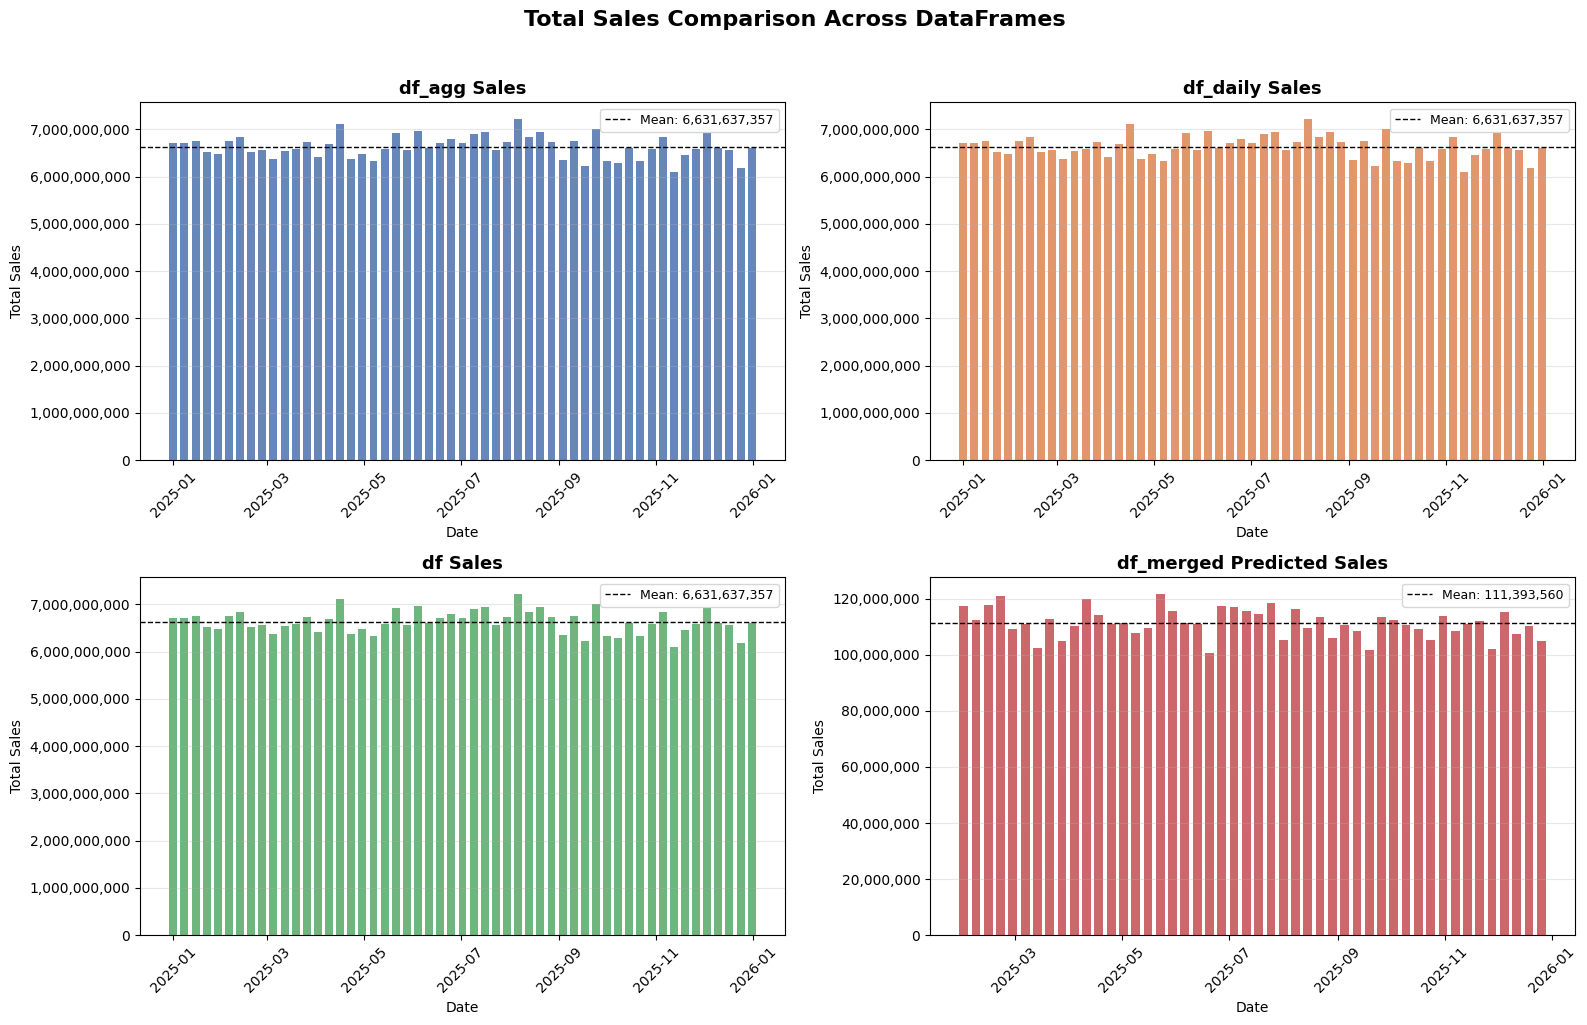

In [94]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Aggregate all sources by date
agg_sales       = df_agg.groupby('date')['sales'].sum().reset_index()
daily_sales     = df_daily.groupby('date')['sales'].sum().reset_index()
df_sales        = df.groupby('date')['sales'].sum().reset_index()
merged_sales    = df_merged.groupby('date')['predicted_sales'].sum().reset_index()

# Sample every 7 days to keep bars readable
agg_sales       = agg_sales.iloc[::7]
daily_sales     = daily_sales.iloc[::7]
df_sales        = df_sales.iloc[::7]
merged_sales    = merged_sales.iloc[::7]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
fig.suptitle('Total Sales Comparison Across DataFrames', fontsize=16, fontweight='bold', y=1.02)

plots = [
    (axes[0, 0], agg_sales,    'date', 'sales',           '#4C72B0', 'df_agg Sales'),
    (axes[0, 1], daily_sales,  'date', 'sales',           '#DD8452', 'df_daily Sales'),
    (axes[1, 0], df_sales,     'date', 'sales',           '#55A868', 'df Sales'),
    (axes[1, 1], merged_sales, 'date', 'predicted_sales', '#C44E52', 'df_merged Predicted Sales'),
]

for ax, data, x_col, y_col, color, title in plots:
    ax.bar(data[x_col], data[y_col], color=color, alpha=0.85, width=5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Total Sales', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='x', rotation=45)
    # Add mean line
    mean_val = data[y_col].mean()
    ax.axhline(mean_val, color='black', linestyle='--', linewidth=1, label=f'Mean: {mean_val:,.0f}')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

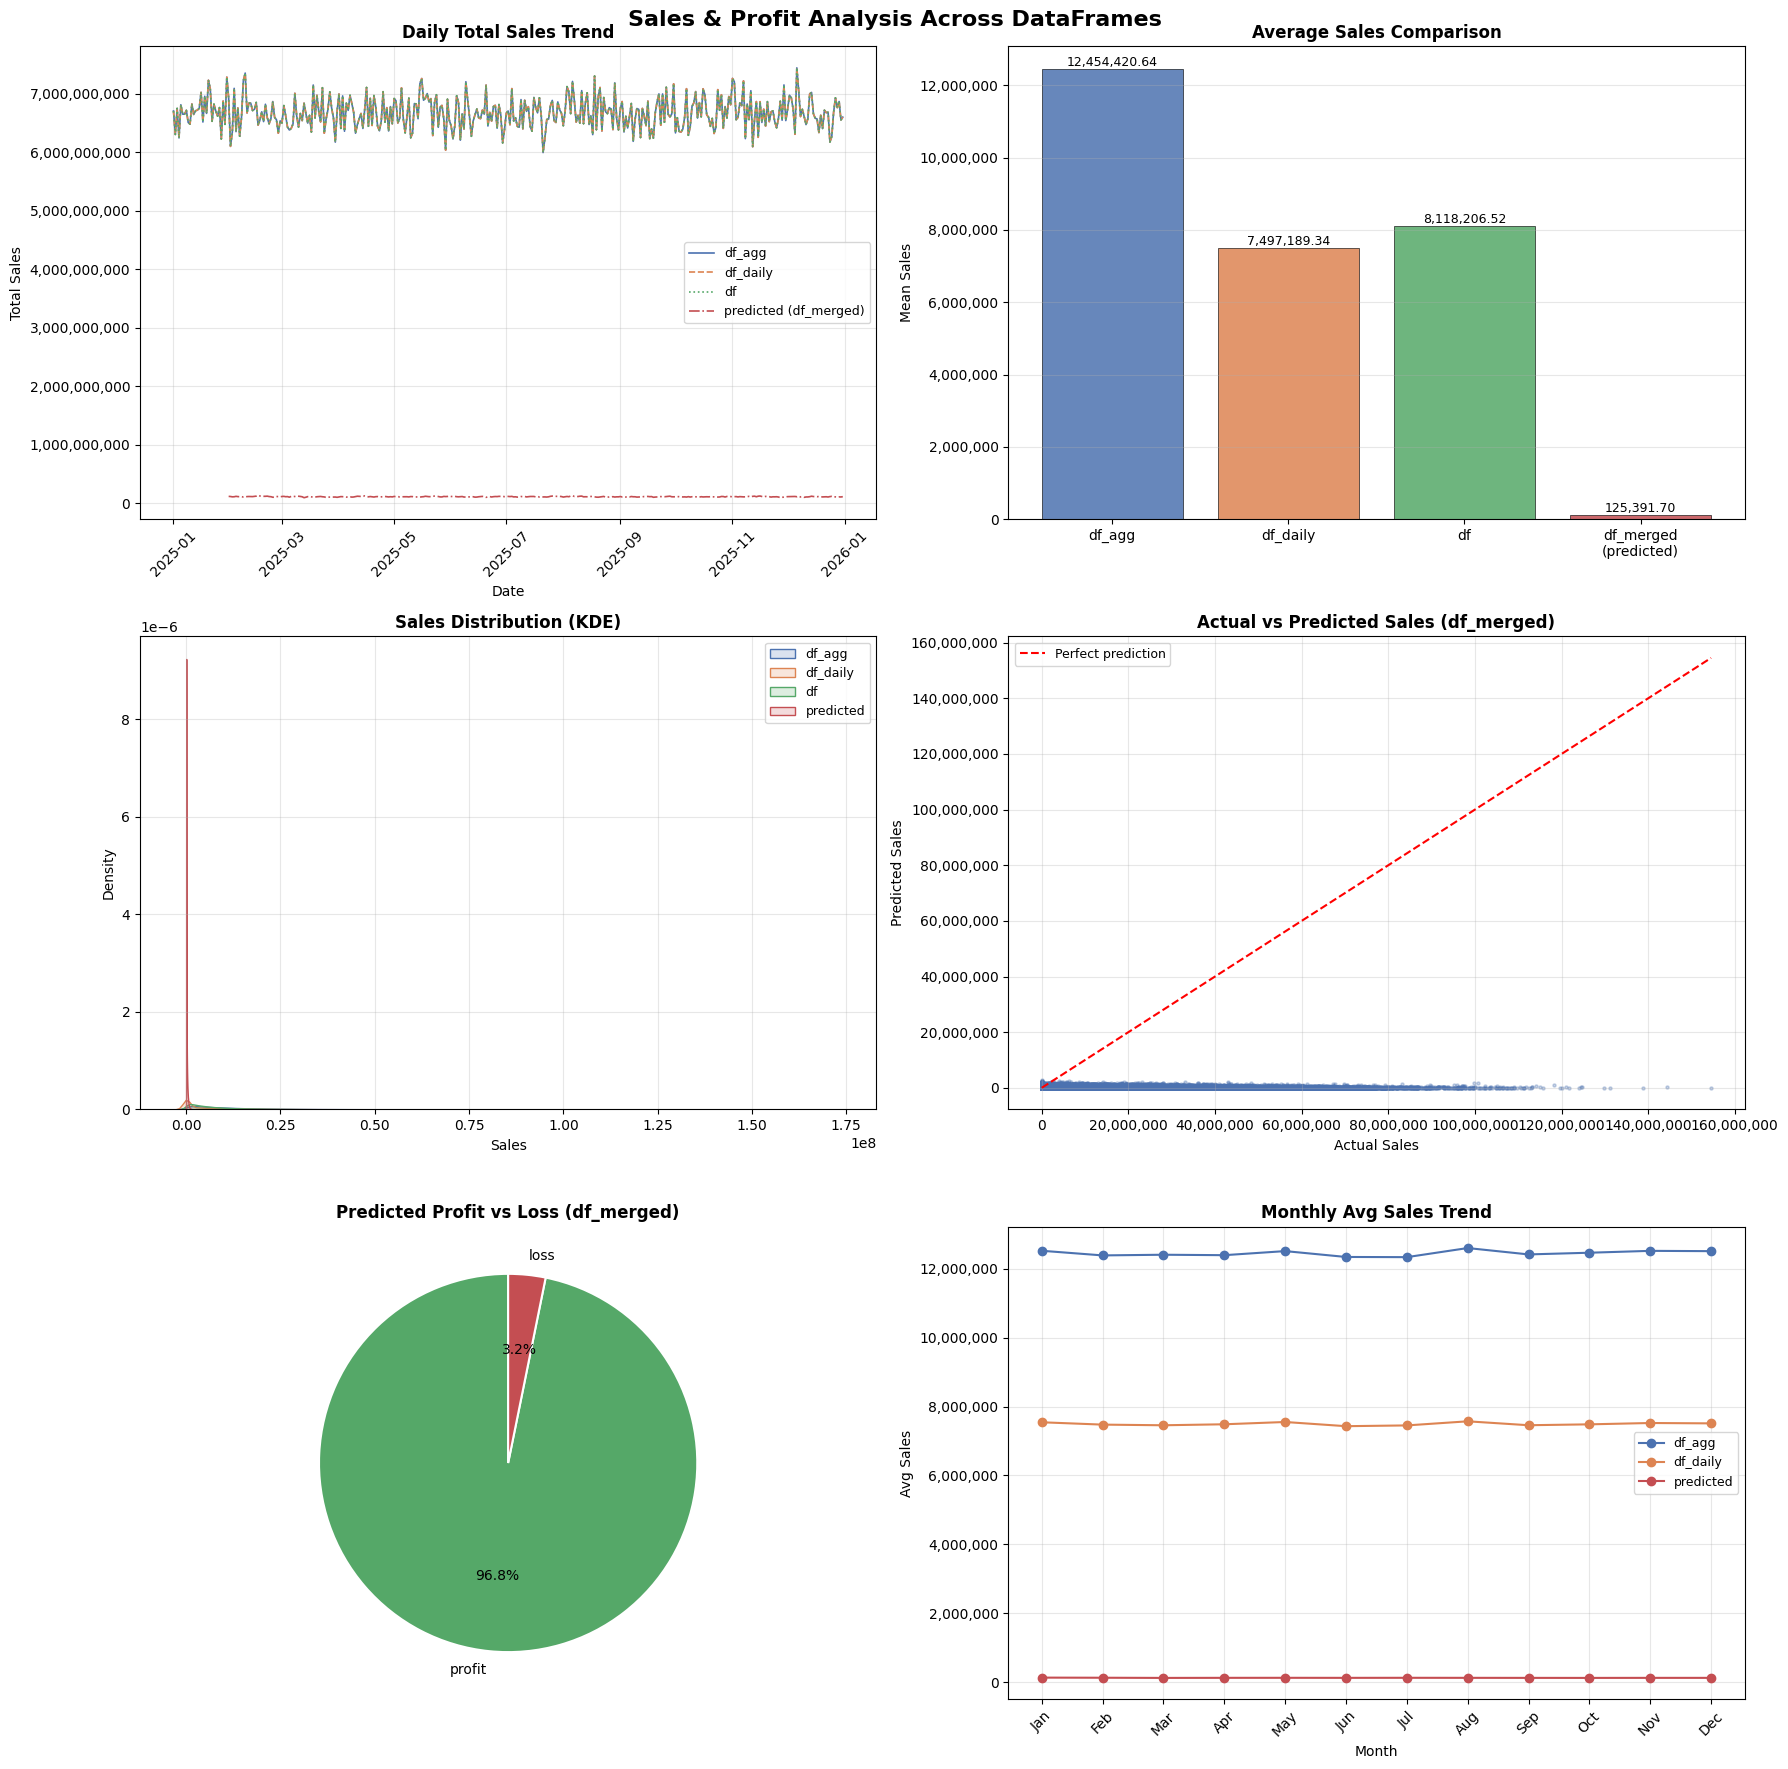

In [95]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Sales & Profit Analysis Across DataFrames', fontsize=16, fontweight='bold')

# ── 1. Daily Sales Trend ─────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(df_agg.groupby('date')['sales'].sum().reset_index()['date'],
        df_agg.groupby('date')['sales'].sum().reset_index()['sales'],
        label='df_agg', color='#4C72B0', linewidth=1.2)
ax.plot(df_daily.groupby('date')['sales'].sum().reset_index()['date'],
        df_daily.groupby('date')['sales'].sum().reset_index()['sales'],
        label='df_daily', color='#DD8452', linewidth=1.2, linestyle='--')
ax.plot(df.groupby('date')['sales'].sum().reset_index()['date'],
        df.groupby('date')['sales'].sum().reset_index()['sales'],
        label='df', color='#55A868', linewidth=1.2, linestyle=':')
ax.plot(df_merged.groupby('date')['predicted_sales'].sum().reset_index()['date'],
        df_merged.groupby('date')['predicted_sales'].sum().reset_index()['predicted_sales'],
        label='predicted (df_merged)', color='#C44E52', linewidth=1.2, linestyle='-.')
ax.set_title('Daily Total Sales Trend', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Total Sales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── 2. Bar: Avg Sales per DataFrame ──────────────────────────────────────────
ax = axes[0, 1]
labels = ['df_agg', 'df_daily', 'df', 'df_merged\n(predicted)']
means  = [
    df_agg['sales'].mean(),
    df_daily['sales'].mean(),
    df['sales'].mean(),
    df_merged['predicted_sales'].mean()
]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax.bar(labels, means, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:,.2f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Average Sales Comparison', fontweight='bold')
ax.set_ylabel('Mean Sales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)

# ── 3. Sales Distribution (KDE) ──────────────────────────────────────────────
ax = axes[1, 0]
sns.kdeplot(df_agg['sales'],   ax=ax, label='df_agg',   color='#4C72B0', fill=True, alpha=0.2)
sns.kdeplot(df_daily['sales'], ax=ax, label='df_daily',  color='#DD8452', fill=True, alpha=0.2)
sns.kdeplot(df['sales'],       ax=ax, label='df',        color='#55A868', fill=True, alpha=0.2)
sns.kdeplot(df_merged['predicted_sales'], ax=ax, label='predicted', color='#C44E52', fill=True, alpha=0.2)
ax.set_title('Sales Distribution (KDE)', fontweight='bold')
ax.set_xlabel('Sales'); ax.set_ylabel('Density')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── 4. Actual vs Predicted Sales Scatter ─────────────────────────────────────
ax = axes[1, 1]
ax.scatter(df_merged['sales'], df_merged['predicted_sales'],
           alpha=0.3, s=5, color='#4C72B0')
max_val = max(df_merged['sales'].max(), df_merged['predicted_sales'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_title('Actual vs Predicted Sales (df_merged)', fontweight='bold')
ax.set_xlabel('Actual Sales'); ax.set_ylabel('Predicted Sales')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── 5. Profit Status Distribution ────────────────────────────────────────────
ax = axes[2, 0]
profit_counts = df_merged['predicted_profit'].value_counts()
wedge_colors  = ['#55A868', '#C44E52']
ax.pie(profit_counts, labels=profit_counts.index, autopct='%1.1f%%',
       colors=wedge_colors, startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Predicted Profit vs Loss (df_merged)', fontweight='bold')

# ── 6. Monthly Avg Sales ──────────────────────────────────────────────────────
ax = axes[2, 1]
def monthly_avg(data, col):
    tmp = data.copy()
    tmp['month'] = pd.to_datetime(tmp['date']).dt.month
    return tmp.groupby('month')[col].mean().reset_index()

for data, col, label, color in [
    (df_agg,    'sales',           'df_agg',    '#4C72B0'),
    (df_daily,  'sales',           'df_daily',  '#DD8452'),
    (df_merged, 'predicted_sales', 'predicted', '#C44E52'),
]:
    m = monthly_avg(data, col)
    ax.plot(m['month'], m[col], marker='o', label=label, color=color, linewidth=1.5)

ax.set_title('Monthly Avg Sales Trend', fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Avg Sales')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()